In [1]:
import sys
from pathlib import Path
_r = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts' / 'config.py').exists())
sys.path.insert(0, str(_r / 'scripts'))

from notebook_init import setup
cfg, PATHS, POPULATIONS, HARD_FILTERS, SITUATIONAL_FILTERS, ML = setup()

from utils import analyze_fst, merge_fst_top_variants, variants_to_bed_file, count_variants
from fst_selection import (
    add_population_to_psam,
    calculate_pairwise_fst,
    find_fst_files,
    analyze_all_fst_files,
    select_top_fst_variants,
    extract_fst_variants,
)
from situational_filters import calculate_pca
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plink import count_variants
import os


Project root : /home/ibmelab/Projects/AISNP_Research
genomes_data : /mnt/data/aisnp_data/1000genomes/
output root  : output


In [2]:
# Configuration
INPUT_PFILE = str(PATHS.PLINK_LD_PRUNED)
SAMPLES_CSV = str(PATHS.EAS_SAMPLES_CSV)
OUTPUT_DIR = str(PATHS.outputs_dir("fst_only/04b_fst_and_pca"))

print(f"Input pfile: {INPUT_PFILE}")
print(f"Samples CSV: {SAMPLES_CSV}")
print(f"FST top N: {SITUATIONAL_FILTERS.FST_TOP_N}")
print(f"Variants: {count_variants(INPUT_PFILE)}")

Input pfile: /mnt/data/aisnp_data/1000genomes/outputs/02_situational_filtering/SEA_JPT_CN_LD_pruned
Samples CSV: /mnt/data/aisnp_data/1000genomes/SEA_JPT_CN_subpopulation_samples.csv
FST top N: 1000
Variants: 614759


## Step 1: Add Population Labels to PSAM

FST calculation requires population labels in the .psam file.

In [3]:
# Add population labels
psam_path = f"{INPUT_PFILE}.psam"

# Create a backup first
import shutil
backup_path = f"{psam_path}.backup"
if not os.path.exists(backup_path):
    shutil.copy(psam_path, backup_path)
    print(f"Backup created: {backup_path}")

# Add population labels
add_population_to_psam(
    psam_path,
    SAMPLES_CSV,
    output_path=psam_path,
)

# Verify
psam_df = pd.read_csv(psam_path, sep="\t")
print("\nUpdated .psam file:")
display(psam_df.head())
print(f"\nPopulation counts:")
display(psam_df['pop'].value_counts())

Added population labels to psam file
  Samples: 504
  Populations: {'CN': 208, 'SEA': 192, 'JPT': 104}

Updated .psam file:


,#IID,pop
0,HG00403,CN
1,HG00404,CN
2,HG00406,CN
3,HG00407,CN
4,HG00409,CN



Population counts:


pop
CN     208
SEA    192
JPT    104
Name: count, dtype: int64

## Step 2: Calculate Pairwise FST

FST (Fixation Index) measures genetic differentiation between populations.
- FST = 0: No differentiation (same allele frequencies)
- FST = 1: Complete differentiation (fixed for different alleles)

In [4]:
# Calculate FST
fst_prefix = calculate_pairwise_fst(
    INPUT_PFILE,
    output_prefix=str(PATHS.FST_RESULTS),
    pop_column="pop",
)

FST CALCULATION
  Input: /mnt/data/aisnp_data/1000genomes/outputs/02_situational_filtering/SEA_JPT_CN_LD_pruned
  Population column: pop
Running: plink2 --threads 16 --pfile /mnt/data/aisnp_data/1000genomes/outputs/02_situational_filtering/SEA_JPT_CN_LD_pruned --fst pop report-variants --out /mnt/data/aisnp_data/1000genomes/cache/fst_only/04b_fst_and_pca/SEA_JPT_CN_FST_RESULTS
PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /mnt/data/aisnp_data/1000genomes/cache/fst_only/04b_fst_and_pca/SEA_JPT_CN_FST_RESULTS.log.
Options in effect:
  --fst pop report-variants
  --out /mnt/data/aisnp_data/1000genomes/cache/fst_only/04b_fst_and_pca/SEA_JPT_CN_FST_RESULTS
  --pfile /mnt/data/aisnp_data/1000genomes/outputs/02_situational_filtering/SEA_JPT_CN_LD_pruned
  --threads 16

Start time: Wed Jun  3 15:30:38 2026
15186 MiB RAM detected, ~10292 available; reserving 7593 MiB for ma

In [5]:
# Find FST files
fst_files = find_fst_files(fst_prefix)

# List pairwise comparisons
print("\nPairwise FST comparisons:")
for f in fst_files:
    print(f"  - {os.path.basename(f)}")

Found 3 FST files:
  - SEA_JPT_CN_FST_RESULTS.JPT.SEA.fst.var
  - SEA_JPT_CN_FST_RESULTS.CN.JPT.fst.var
  - SEA_JPT_CN_FST_RESULTS.CN.SEA.fst.var

Pairwise FST comparisons:
  - SEA_JPT_CN_FST_RESULTS.JPT.SEA.fst.var
  - SEA_JPT_CN_FST_RESULTS.CN.JPT.fst.var
  - SEA_JPT_CN_FST_RESULTS.CN.SEA.fst.var


## Step 3: Analyze FST Distribution

In [6]:
# Analyze all FST files
all_fst, top_fst = analyze_all_fst_files(
    fst_prefix,
    top_n=SITUATIONAL_FILTERS.FST_TOP_N,
    plot=False,
)

Found 3 FST files:
  - SEA_JPT_CN_FST_RESULTS.JPT.SEA.fst.var
  - SEA_JPT_CN_FST_RESULTS.CN.JPT.fst.var
  - SEA_JPT_CN_FST_RESULTS.CN.SEA.fst.var

Analyzing: JPT.SEA
Loading FST file: /mnt/data/aisnp_data/1000genomes/cache/fst_only/04b_fst_and_pca/SEA_JPT_CN_FST_RESULTS.JPT.SEA.fst.var
  614759 variants | NaN: 24979 | pos: 350803

Analyzing: CN.JPT
Loading FST file: /mnt/data/aisnp_data/1000genomes/cache/fst_only/04b_fst_and_pca/SEA_JPT_CN_FST_RESULTS.CN.JPT.fst.var
  614759 variants | NaN: 25410 | pos: 326124

Analyzing: CN.SEA
Loading FST file: /mnt/data/aisnp_data/1000genomes/cache/fst_only/04b_fst_and_pca/SEA_JPT_CN_FST_RESULTS.CN.SEA.fst.var
  614759 variants | NaN: 14097 | pos: 298593


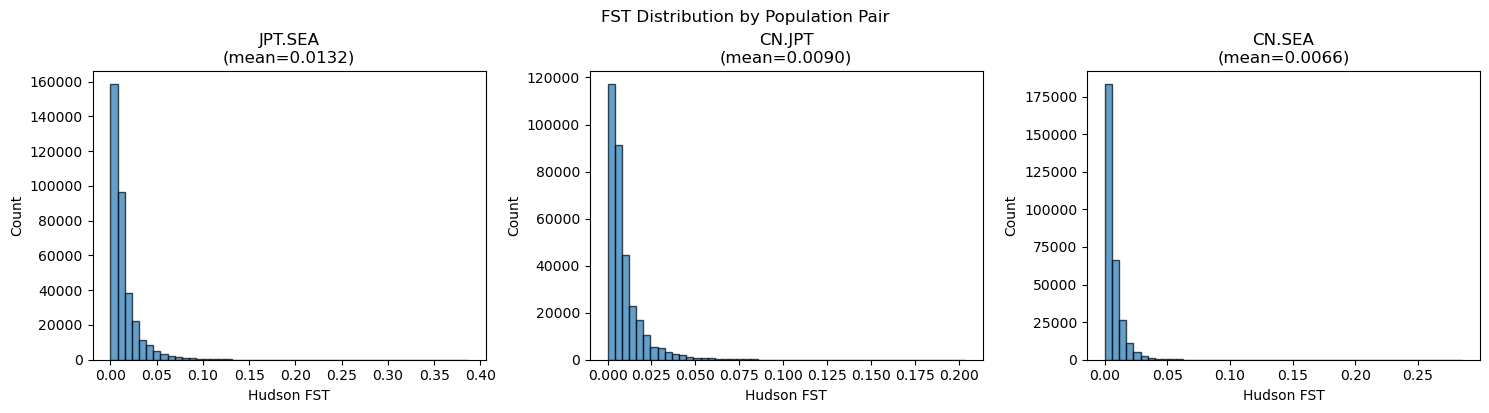

In [7]:
# Visualize FST distributions
n_comparisons = len(all_fst)
fig, axes = plt.subplots(1, n_comparisons, figsize=(5*n_comparisons, 4))

if n_comparisons == 1:
    axes = [axes]

for ax, (comparison, df) in zip(axes, all_fst.items()):
    fst_valid = df['HUDSON_FST'].dropna()
    fst_positive = fst_valid[fst_valid > 0]
    
    ax.hist(fst_positive, bins=50, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Hudson FST')
    ax.set_ylabel('Count')
    ax.set_title(f'{comparison}\n(mean={fst_positive.mean():.4f})')

plt.tight_layout()
plt.suptitle('FST Distribution by Population Pair', y=1.02)
plt.show()

In [8]:
# Summary statistics for each comparison
print("FST Summary Statistics:")
print("="*60)

for comparison, df in all_fst.items():
    fst_valid = df['HUDSON_FST'].dropna()
    fst_positive = fst_valid[fst_valid > 0]
    
    print(f"\n{comparison}:")
    print(f"  Total variants: {len(df)}")
    print(f"  Valid FST: {len(fst_valid)}")
    print(f"  Positive FST: {len(fst_positive)}")
    print(f"  Mean FST: {fst_positive.mean():.6f}")
    print(f"  Max FST: {fst_positive.max():.6f}")

FST Summary Statistics:

JPT.SEA:
  Total variants: 614759
  Valid FST: 589780
  Positive FST: 350803
  Mean FST: 0.013243
  Max FST: 0.386240

CN.JPT:
  Total variants: 614759
  Valid FST: 589349
  Positive FST: 326124
  Mean FST: 0.008990
  Max FST: 0.203482

CN.SEA:
  Total variants: 614759
  Valid FST: 600662
  Positive FST: 298593
  Mean FST: 0.006622
  Max FST: 0.285170


## Step 4: Select Top FST Variants

In [9]:
# Select top variants
merged_df, top_snps_file = select_top_fst_variants(
    fst_prefix,
    output_file=str(PATHS.TOP_SNPS_FILE),
    top_n=SITUATIONAL_FILTERS.FST_TOP_N,
)

print(f"\nTop FST variants:")
display(merged_df.head(10))

Found 3 FST files:
  - SEA_JPT_CN_FST_RESULTS.JPT.SEA.fst.var
  - SEA_JPT_CN_FST_RESULTS.CN.JPT.fst.var
  - SEA_JPT_CN_FST_RESULTS.CN.SEA.fst.var

Analyzing: JPT.SEA
Loading FST file: /mnt/data/aisnp_data/1000genomes/cache/fst_only/04b_fst_and_pca/SEA_JPT_CN_FST_RESULTS.JPT.SEA.fst.var
  614759 variants | NaN: 24979 | pos: 350803

Analyzing: CN.JPT
Loading FST file: /mnt/data/aisnp_data/1000genomes/cache/fst_only/04b_fst_and_pca/SEA_JPT_CN_FST_RESULTS.CN.JPT.fst.var
  614759 variants | NaN: 25410 | pos: 326124

Analyzing: CN.SEA
Loading FST file: /mnt/data/aisnp_data/1000genomes/cache/fst_only/04b_fst_and_pca/SEA_JPT_CN_FST_RESULTS.CN.SEA.fst.var
  614759 variants | NaN: 14097 | pos: 298593
Merged 3 FST tables → 2508 unique variants

FST VARIANT SELECTION SUMMARY
  Top N per comparison: 1000
  Number of comparisons: 3
  Total unique variants: 2508

Variant list saved: /mnt/data/aisnp_data/1000genomes/outputs/fst_only/04b_fst_and_pca/top_snps.txt

Top FST variants:


,#CHROM,POS,ID,OBS_CT,HUDSON_FST
0,6,31603591,"6:31603591[b37]A,G",296,0.386240
1,19,54792079,"19:54792079[b37]G,T",296,0.347395
2,17,72054724,"17:72054724[b37]C,T",296,0.254177
3,14,106286458,"14:106286458[b37]A,G",296,0.250414
4,20,12928988,"20:12928988[b37]T,G",296,0.250124
5,4,17813761,"4:17813761[b37]G,A",296,0.245431
6,18,18518431,"18:18518431[b37]G,T",296,0.244773
7,16,89755216,"16:89755216[b37]A,G",296,0.243531
8,1,12387655,"1:12387655[b37]G,A",296,0.240209
9,1,80875078,"1:80875078[b37]G,A",296,0.239836


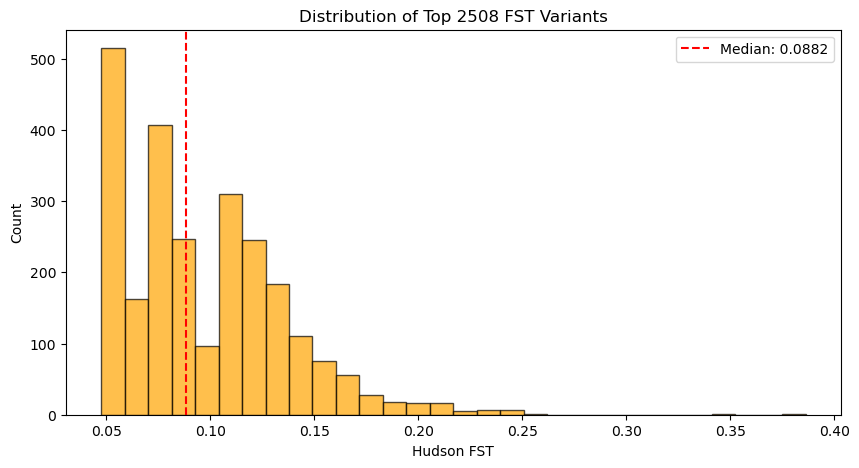

In [10]:
# Visualize top FST variants
plt.figure(figsize=(10, 5))

plt.hist(merged_df['HUDSON_FST'], bins=30, edgecolor='black', alpha=0.7, color='orange')
plt.xlabel('Hudson FST')
plt.ylabel('Count')
plt.title(f'Distribution of Top {len(merged_df)} FST Variants')
plt.axvline(merged_df['HUDSON_FST'].median(), color='red', linestyle='--', 
            label=f'Median: {merged_df["HUDSON_FST"].median():.4f}')
plt.legend()
plt.show()

In [11]:
# Convert to BED format
bed_file = str(PATHS.TOP_SNPS_BED)
variants_to_bed_file(top_snps_file, bed_file)

Wrote 2508 variants → /mnt/data/aisnp_data/1000genomes/outputs/fst_only/04b_fst_and_pca/top_snps.bed


2508

## Step 5: Extract FST-Selected Variants

In [12]:
# Extract variants
fst_filtered = extract_fst_variants(
    str(PATHS.PLINK_UNIQUE_IDS),  # Use pfile with unique IDs
    top_snps_file,
    output_pfile=str(PATHS.FST_FILTERED),
)

print(f"\nExtracted variants: {count_variants(fst_filtered)}")

Extracting FST-selected variants...
Running: plink2 --threads 16 --pfile /mnt/data/aisnp_data/1000genomes/cache/02_situational_filtering/SEA_JPT_CN_unique_ids --extract /mnt/data/aisnp_data/1000genomes/outputs/fst_only/04b_fst_and_pca/top_snps.txt --make-pgen --out /mnt/data/aisnp_data/1000genomes/outputs/fst_only/04b_fst_and_pca/FST_FILTERED
PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /mnt/data/aisnp_data/1000genomes/outputs/fst_only/04b_fst_and_pca/FST_FILTERED.log.
Options in effect:
  --extract /mnt/data/aisnp_data/1000genomes/outputs/fst_only/04b_fst_and_pca/top_snps.txt
  --make-pgen
  --out /mnt/data/aisnp_data/1000genomes/outputs/fst_only/04b_fst_and_pca/FST_FILTERED
  --pfile /mnt/data/aisnp_data/1000genomes/cache/02_situational_filtering/SEA_JPT_CN_unique_ids
  --threads 16

Start time: Wed Jun  3 15:30:42 2026
15186 MiB RAM detected, ~9599 available; r

## Step 6: PCA Analysis

In [13]:
# Calculate PCA on FST-selected variants
pca_prefix = calculate_pca(
    fst_filtered,
    output_prefix=str(PATHS.PCA_FILE),
    n_components=10,
)

SITUATIONAL: PCA Calculation
  Components: 10
Running: plink2 --threads 16 --pfile /mnt/data/aisnp_data/1000genomes/outputs/fst_only/04b_fst_and_pca/FST_FILTERED --pca 10 --out /mnt/data/aisnp_data/1000genomes/outputs/fst_only/04b_fst_and_pca/FST_PCA
PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /mnt/data/aisnp_data/1000genomes/outputs/fst_only/04b_fst_and_pca/FST_PCA.log.
Options in effect:
  --out /mnt/data/aisnp_data/1000genomes/outputs/fst_only/04b_fst_and_pca/FST_PCA
  --pca 10
  --pfile /mnt/data/aisnp_data/1000genomes/outputs/fst_only/04b_fst_and_pca/FST_FILTERED
  --threads 16

Start time: Wed Jun  3 15:30:48 2026
15186 MiB RAM detected, ~9620 available; reserving 7593 MiB for main workspace.
Using up to 16 threads (change this with --threads).
504 samples (0 females, 0 males, 504 ambiguous; 504 founders) loaded from
/mnt/data/aisnp_data/1000genomes/outputs

In [14]:
# Load PCA results
eigenvec = pd.read_csv(f"{pca_prefix}.eigenvec", sep=r"\s+", header=None)
eigenvec.columns = ["#IID"] + [f"PC{i}" for i in range(1, 11)]

eigenval = pd.read_csv(f"{pca_prefix}.eigenval", header=None)
eigenval.columns = ["eigenvalue"]

# Merge with population labels
pop_df = pd.read_csv(SAMPLES_CSV, header=None)
pop_df.columns = ["#IID", "POP", "SUPER_POP"]

pca_df = eigenvec.merge(pop_df[["#IID", "POP"]], on="#IID")

print(f"PCA results: {len(pca_df)} samples")
display(pca_df.head())

PCA results: 504 samples


,#IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,POP
0,HG00403,-0.0131303,0.0904353,0.0223836,-0.0557421,0.04559,0.0600006,-0.00120362,-0.0524783,0.0158865,-0.0617523,CN
1,HG00404,-0.0173318,0.0740506,0.0181526,-0.0450933,0.000789384,0.117914,-0.0695166,-0.0783008,0.0391397,-0.0211662,CN
2,HG00406,0.006585,0.00222495,-0.0398094,0.00335276,0.00193692,0.0198697,-0.0220723,-0.00261157,-0.000266028,0.00440281,CN
3,HG00407,0.00940249,0.0266022,-0.0355688,0.00715026,0.00951505,0.00212463,-0.0220639,0.0178239,-0.0240718,0.0063922,CN
4,HG00409,0.00597755,-0.0132444,-0.0457659,-0.0521078,0.00464405,0.0596236,0.0391185,0.0513919,0.00971359,0.0380482,CN


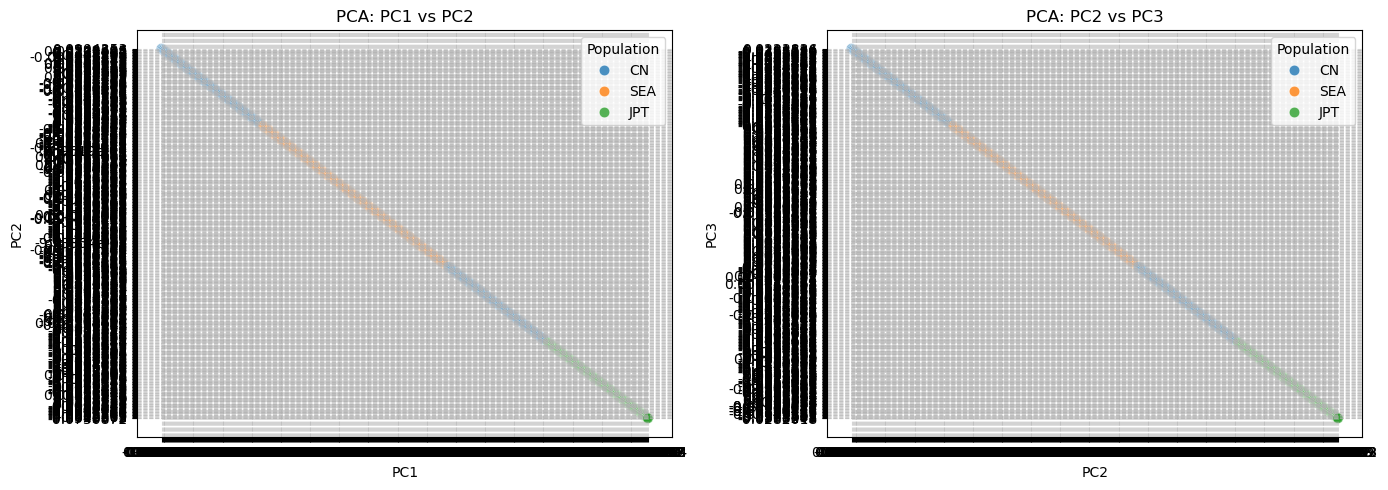

In [15]:
# Plot PC1 vs PC2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PC1 vs PC2
sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="POP",
    palette="tab10",
    s=60, alpha=0.8,
    ax=axes[0],
)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PCA: PC1 vs PC2")
axes[0].legend(title="Population")
axes[0].grid(True, linestyle="--", alpha=0.5)

# PC2 vs PC3
sns.scatterplot(
    data=pca_df,
    x="PC2", y="PC3",
    hue="POP",
    palette="tab10",
    s=60, alpha=0.8,
    ax=axes[1],
)
axes[1].set_xlabel("PC2")
axes[1].set_ylabel("PC3")
axes[1].set_title("PCA: PC2 vs PC3")
axes[1].legend(title="Population")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

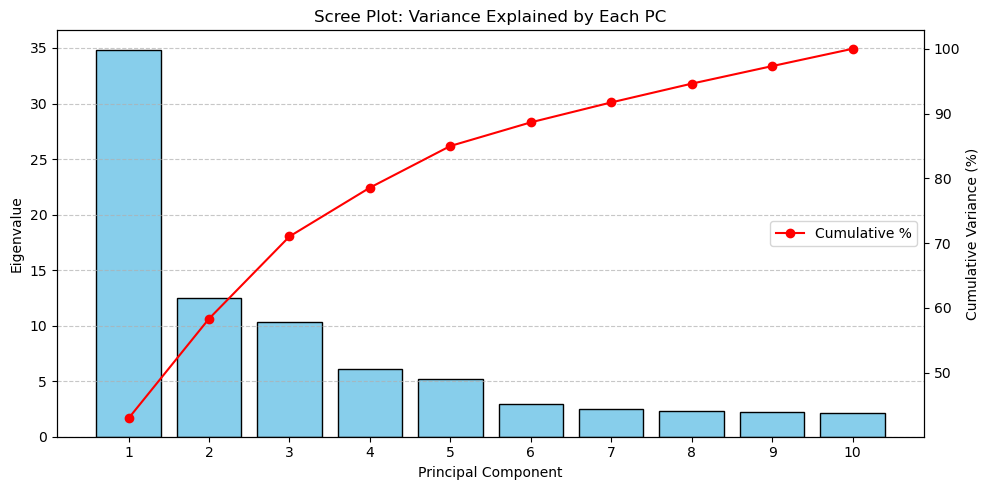

In [16]:
# Scree plot
plt.figure(figsize=(10, 5))

plt.bar(range(1, len(eigenval) + 1), eigenval["eigenvalue"], color='skyblue', edgecolor='black')
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot: Variance Explained by Each PC")
plt.xticks(range(1, len(eigenval) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add cumulative variance line
cumvar = eigenval["eigenvalue"].cumsum() / eigenval["eigenvalue"].sum() * 100
ax2 = plt.twinx()
ax2.plot(range(1, len(eigenval) + 1), cumvar, 'r-o', label='Cumulative %')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.legend(loc='right')

plt.tight_layout()
plt.show()

## Summary

In [17]:
print("="*60)
print("FST AND PCA SUMMARY")
print("="*60)
print(f"\nFST Analysis:")
print(f"  Population comparisons: {len(all_fst)}")
print(f"  Top N per comparison: {SITUATIONAL_FILTERS.FST_TOP_N}")
print(f"  Total unique top variants: {len(merged_df)}")
print(f"\nPCA:")
print(f"  Samples: {len(pca_df)}")
print(f"  Components: 10")
print(f"  Variance explained (PC1+PC2): {cumvar.iloc[1]:.1f}%")
print(f"\nOutput files:")
print(f"  - Top SNPs: {top_snps_file}")
print(f"  - BED file: {bed_file}")
print(f"  - FST filtered pfile: {fst_filtered}")
print(f"  - PCA results: {pca_prefix}.eigenvec")
print(f"\nNext step: Run 04_ml_training.ipynb")

FST AND PCA SUMMARY

FST Analysis:
  Population comparisons: 3
  Top N per comparison: 1000
  Total unique top variants: 2508

PCA:
  Samples: 504
  Components: 10
  Variance explained (PC1+PC2): 58.3%

Output files:
  - Top SNPs: /mnt/data/aisnp_data/1000genomes/outputs/fst_only/04b_fst_and_pca/top_snps.txt
  - BED file: /mnt/data/aisnp_data/1000genomes/outputs/fst_only/04b_fst_and_pca/top_snps.bed
  - FST filtered pfile: /mnt/data/aisnp_data/1000genomes/outputs/fst_only/04b_fst_and_pca/FST_FILTERED
  - PCA results: /mnt/data/aisnp_data/1000genomes/outputs/fst_only/04b_fst_and_pca/FST_PCA.eigenvec

Next step: Run 04_ml_training.ipynb
